<a href="https://colab.research.google.com/github/Jason-1119/Object-Detection-by-Yolo8-on-Pascal-Voc-2007/blob/main/trainmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.7 MB/s eta 0:00:00


In [4]:
import os
import shutil
import numpy
import ultralytics
import xml.etree.ElementTree as ET
from pathlib import Path
from tqdm import tqdm


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
yaml_text = """path: /content/drive/MyDrive/Colab Notebooks/OD/voc2007_yolo
train: images/train
val: images/val

names:
  0: aeroplane
  1: bicycle
  2: bird
  3: boat
  4: bottle
  5: bus
  6: car
  7: cat
  8: chair
  9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor
"""
yaml_path = "/content/drive/MyDrive/Colab Notebooks/OD/voc.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_text)

print("rewrote:", yaml_path)

rewrote: /content/drive/MyDrive/Colab Notebooks/OD/voc.yaml


In [19]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Colab Notebooks/OD/yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/Colab Notebooks/OD/voc.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    cache=True
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/OD/voc.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Colab Notebooks/OD/yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train8, nbs=64, nms=False, opset=None, optimize=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d6c595d4380>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043

In [20]:
model = YOLO("/content/runs/detect/train8/weights/best.pt")

In [22]:
results = model.predict(
    source="/content/drive/MyDrive/Colab Notebooks/OD/voc2007_yolo/images/val/000005.jpg",
    imgsz=640,
    conf=0.25,
    save=True
)


image 1/1 /content/drive/MyDrive/Colab Notebooks/OD/voc2007_yolo/images/val/000005.jpg: 480x640 4 chairs, 1 person, 42.1ms
Speed: 2.6ms preprocess, 42.1ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


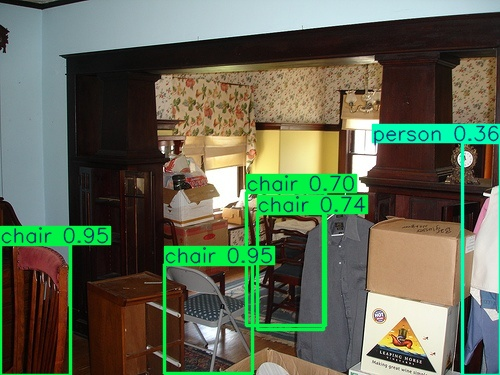

In [23]:
from glob import glob
from IPython.display import Image, display

pred_dir = sorted(glob("runs/detect/predict*"))[-1]
display(Image(f"{pred_dir}/000005.jpg"))


image 1/1 /content/drive/MyDrive/Colab Notebooks/OD/voc2007_yolo/images/val/000050.jpg: 480x640 6 bottles, 1 chair, 7 persons, 8.4ms
Speed: 3.2ms preprocess, 8.4ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


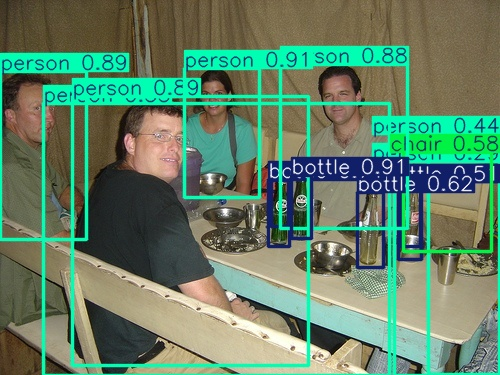

In [24]:
results2 = model.predict(
    source="/content/drive/MyDrive/Colab Notebooks/OD/voc2007_yolo/images/val/000050.jpg",
    imgsz=640,
    conf=0.25,
    save=True
)
pred_dir = sorted(glob("runs/detect/predict*"))[-1]
display(Image(f"{pred_dir}/000050.jpg"))